Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 100, 64)           │             256 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 100)               │          10,100 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 100, 64)           │          12,352 │ conv1d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 100)               │          10,100 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 100)               │          66,000 │ conv1d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 100)               │          10,100 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 100)               │          10,100 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 100)               │               0 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 200)               │               0 │ dense[0][0], flatten[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 100)               │          20,100 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 100)               │          10,100 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 1)                 │             101 │ dense_5[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 149,309 (583.24 KB)

 Trainable params: 149,309 (583.24 KB)

 Non-trainable params: 0 (0.00 B)

Training epoch 1/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8336 - loss: 0.3363 - val_accuracy: 0.9543 - val_loss: 0.1234
Training epoch 2/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9705 - loss: 0.0860 - val_accuracy: 0.9579 - val_loss: 0.1253
Training epoch 3/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9840 - loss: 0.0533 - val_accuracy: 0.9579 - val_loss: 0.1261
Training epoch 4/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9909 - loss: 0.0299 - val_accuracy: 0.9628 - val_loss: 0.1173
Training epoch 5/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9921 - loss: 0.0218 - val_accuracy: 0.9640 - val_loss: 0.1406
Training epoch 6/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9919 - loss: 0.0220 - val_accuracy: 0.9604 - val_loss: 0.1440
Training epoch 7/80
205/205 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9952 - loss: 0.0132 - val_accuracy: 0.9573 - val_loss: 0.1650
Training epoch 8/80
205/205 ━━━━━━

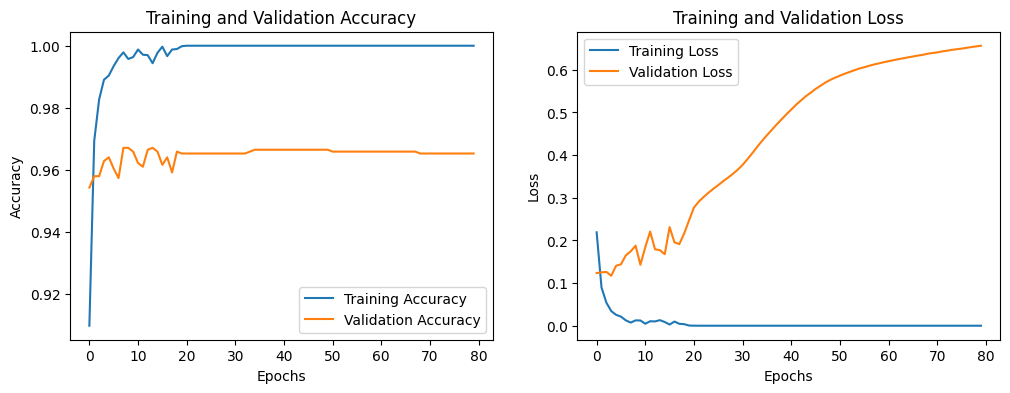

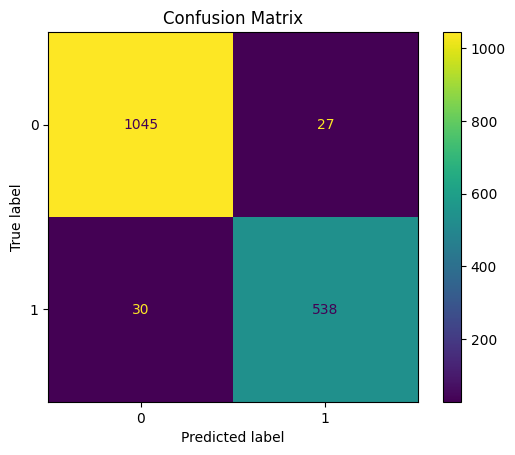

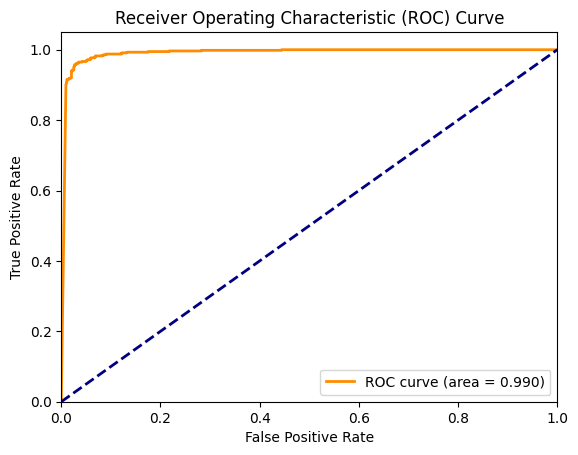

In [2]:
#1DCNN-LSTM_BoAW_MFCC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Flatten, concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import History
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
import os
import numpy as np

# Ensure TensorFlow uses CPU
tf.config.set_visible_devices([], 'GPU')

# Load CSV data
data = pd.read_csv('CMDC_BoAWMFCC_features.csv')
train_data, test_data = train_test_split(data, test_size=0.20, random_state=42)
X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values
X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data to fit the 1D CNN
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Network parameters
input_shape = (X_train.shape[1], 1)  # Adapt input shape
lstm_units = 100
fnn_units = 100
num_classes = 1  # Binary classification

# Build 1D CNN + LSTM model
input_tensor = Input(shape=input_shape)
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_tensor)
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
x = LSTM(lstm_units)(x)
lstm_output = Dense(fnn_units, activation='relu')(x)

# Build separate FNN model
fnn_input = Input(shape=(X_train.shape[1],))
y = Dense(fnn_units, activation='relu')(fnn_input)
y = Dense(fnn_units, activation='relu')(y)
y = Dense(fnn_units, activation='relu')(y)
fnn_output = Flatten()(y)

# Combine outputs of both models
combined = concatenate([lstm_output, fnn_output])

# Add final dense layers for classification
z = Dense(100, activation='relu')(combined)
z = Dense(100, activation='relu')(z)
output = Dense(num_classes, activation='sigmoid')(z)  # Binary classification

# Create model
model = Model(inputs=[input_tensor, fnn_input], outputs=output)

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()
# Plot model structure
plot_model(model, to_file='model_plot.png', show_shapes=True)

# Define a function to train the model incrementally
def incremental_train(model, X_train_cnn, X_train, y_train, X_test_cnn, X_test, y_test, epochs_per_training=1, total_epochs=5):
    history_combined = {
        'accuracy': [],
        'val_accuracy': [],
        'loss': [],
        'val_loss': []
    }
    for epoch in range(total_epochs):
        print(f"Training epoch {epoch + 1}/{total_epochs}")
        history = model.fit([X_train_cnn, X_train], y_train, epochs=epochs_per_training, batch_size=32, validation_data=([X_test_cnn, X_test], y_test), verbose=1)
        
        # Save the model after each training session
        model.save(f'model_epoch_{epoch + 1}.keras')

        # Combine history
        for key in history.history:
            history_combined[key].extend(history.history[key])
    
    return history_combined

# Train the model incrementally and save it
history_combined = incremental_train(model, X_train_cnn, X_train, y_train, X_test_cnn, X_test, y_test, epochs_per_training=1, total_epochs=80)

# Predict and evaluate
y_pred_prob = model.predict([X_test_cnn, X_test])
y_pred = (y_pred_prob > 0.5).astype("int32")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}')
print(f'ROC AUC: {roc_auc:.3f}')

# Plot combined training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_combined['accuracy'], label='Training Accuracy')
plt.plot(history_combined['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_combined['loss'], label='Training Loss')
plt.plot(history_combined['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(conf_matrix).plot()
plt.title('Confusion Matrix')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


